# CIFAR-10 Cached Workflow With a Smaller First Pass

This notebook keeps the full CIFAR-10 training cache on disk, then starts with a smaller subset so you can get a rough result faster before scaling up.

Environment note: this project is managed with `uv` (`uv sync` to install or update dependencies).

## 1) Imports and Paths
Getting all the tools and setting up where to keep our data and cache.

In [1]:
# Import libraries and define reusable project paths.
from pathlib import Path
import tarfile
import pickle

import numpy as np

CIFAR10_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
CACHE_DIR = DATA_DIR / "cache"

ARCHIVE_PATH = RAW_DIR / "cifar-10-python.tar.gz"
EXTRACTED_DIR = RAW_DIR / "cifar-10-batches-py"
CACHE_SAMPLE_COUNT = 50_000
CACHE_PATH = CACHE_DIR / f"cifar10_{CACHE_SAMPLE_COUNT}.npz"

CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

RAW_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

## 2) Helper Functions
Some utility functions to download, load, and split the data safely.

In [2]:
# Define reusable helpers for safe extraction and batch loading.
def _safe_extract(tar: tarfile.TarFile, path: Path) -> None:
    base = path.resolve()
    for member in tar.getmembers():
        member_path = (path / member.name).resolve()
        if not str(member_path).startswith(str(base)):
            raise RuntimeError(f"Unsafe path in tar file: {member.name}")
    tar.extractall(path=path)


def download_and_extract_cifar10() -> None:
    import urllib.request

    if EXTRACTED_DIR.exists():
        print(f"Dataset already extracted at: {EXTRACTED_DIR}")
        return

    if not ARCHIVE_PATH.exists():
        print("Downloading CIFAR-10 archive...")
        urllib.request.urlretrieve(CIFAR10_URL, ARCHIVE_PATH)
        print(f"Saved archive to: {ARCHIVE_PATH}")
    else:
        print(f"Archive already exists at: {ARCHIVE_PATH}")

    print("Extracting archive...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        _safe_extract(tar, RAW_DIR)
    print(f"Extracted to: {EXTRACTED_DIR}")


def load_cifar_batch(batch_file: Path):
    import warnings

    with batch_file.open("rb") as f:
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                category=Warning,
                message=r".*align should be passed as Python or NumPy boolean.*",
            )
            batch = pickle.load(f, encoding="bytes")

    images = batch[b"data"]
    labels = np.array(batch[b"labels"], dtype=np.int64)

    images = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return images, labels


def load_all_cifar_training_batches(extracted_dir: Path):
    image_batches = []
    label_batches = []

    for batch_index in range(1, 6):
        batch_file = extracted_dir / f"data_batch_{batch_index}"
        batch_images, batch_labels = load_cifar_batch(batch_file)
        image_batches.append(batch_images)
        label_batches.append(batch_labels)

    images = np.concatenate(image_batches, axis=0)
    labels = np.concatenate(label_batches, axis=0)
    return images, labels


def split_dataset(images: np.ndarray, labels: np.ndarray, train_ratio: float, test_ratio: float, val_ratio: float, seed: int = 42):
    ratio_sum = train_ratio + test_ratio + val_ratio
    if not np.isclose(ratio_sum, 1.0):
        raise ValueError(f"train_ratio + test_ratio + val_ratio must be 1.0, got {ratio_sum:.4f}")

    n = len(images)
    rng = np.random.default_rng(seed)
    indices = np.arange(n)
    rng.shuffle(indices)

    train_end = int(n * train_ratio)
    test_end = train_end + int(n * test_ratio)

    train_idx = indices[:train_end]
    test_idx = indices[train_end:test_end]
    val_idx = indices[test_end:]

    return {
        "X_train": images[train_idx],
        "y_train": labels[train_idx],
        "X_test": images[test_idx],
        "y_test": labels[test_idx],
        "X_val": images[val_idx],
        "y_val": labels[val_idx],
    }

## 3) Build or Load Full Cache, Then Pick a Smaller Working Set
This part keeps the full 50k cache on disk, then picks a smaller subset for quicker training runs. You can raise it later when you want the stronger result.

In [3]:
# Build or load the full 50,000-image cache, then choose a smaller working set for faster experiments.
TRAIN_RATIO = 0.7
TEST_RATIO = 0.2
VAL_RATIO = 0.1
SEED = 42
WORKING_SAMPLE_COUNT = 50_000

if CACHE_PATH.exists():
    print(f"Loading cached dataset from: {CACHE_PATH}")
    with np.load(CACHE_PATH) as cached:
        full_images = cached["images"]
        full_labels = cached["labels"]
        class_names = cached["class_names"].tolist()
else:
    print("Cache not found. Building 50,000-image cache from CIFAR-10...")
    download_and_extract_cifar10()

    full_images, full_labels = load_all_cifar_training_batches(EXTRACTED_DIR)
    class_names = CLASS_NAMES

    np.savez_compressed(
        CACHE_PATH,
        images=full_images.astype(np.uint8),
        labels=full_labels.astype(np.int64),
        class_names=np.array(class_names),
    )
    print(f"Cache saved to: {CACHE_PATH}")

working_sample_count = min(WORKING_SAMPLE_COUNT, len(full_images))
rng = np.random.default_rng(SEED)
selected_indices = rng.choice(len(full_images), size=working_sample_count, replace=False)

images = full_images[selected_indices]
labels = full_labels[selected_indices]

splits = split_dataset(images, labels, TRAIN_RATIO, TEST_RATIO, VAL_RATIO, seed=SEED)

X_train, y_train = splits["X_train"], splits["y_train"]
X_test, y_test = splits["X_test"], splits["y_test"]
X_val, y_val = splits["X_val"], splits["y_val"]

print("Done.")
print(f"full cache size: {len(full_images):,}")
print(f"working sample count: {working_sample_count:,}")
print(f"images shape: {images.shape}")
print(f"labels shape: {labels.shape}")
print(f"unique classes: {len(set(labels.tolist()))}")
print()
print(f"Train set: {X_train.shape[0]} samples ({TRAIN_RATIO:.0%})")
print(f"Test set: {X_test.shape[0]} samples ({TEST_RATIO:.0%})")
print(f"Validation set: {X_val.shape[0]} samples ({VAL_RATIO:.0%})")

Loading cached dataset from: data\cache\cifar10_50000.npz
Done.
full cache size: 50,000
working sample count: 50,000
images shape: (50000, 32, 32, 3)
labels shape: (50000,)
unique classes: 10

Train set: 35000 samples (70%)
Test set: 10000 samples (20%)
Validation set: 5000 samples (10%)


## 4) Quick Sanity Check
Let's peek at a few labels from each split to make sure everything loaded correctly.

In [50]:
# Validate class labels and inspect first labels from each data split.
print("Train labels (first 10):", y_train[:10].tolist())
print("Test labels (first 10):", y_test[:10].tolist())
print("Validation labels (first 10):", y_val[:10].tolist())
print("First train label name:", class_names[int(y_train[0])])

Train labels (first 10): [8, 1, 3, 9, 9, 8, 2, 4, 6, 2]
Test labels (first 10): [5, 9, 9, 6, 1, 8, 7, 1, 6, 2]
Validation labels (first 10): [7, 0, 1, 2, 0, 0, 0, 5, 8, 4]
First train label name: ship


## 5) CNN Basics: Sequential, Conv2D, and Pooling
Quick primer on what we are building with.

- Sequential is just layers stacked on top of each other in order.
- Conv2D learns to spot features like edges and textures with small 3x3 filters.
- MaxPooling2D shrinks the feature maps so we process less stuff.

Put them together and you get a CNN that learns image patterns progressively.

## 6) Technique Summary
The goal here is to keep runtime reasonable without giving up too much accuracy.

- Keep the full CIFAR-10 cache on disk so you do not rebuild data every time.
- Start with a smaller reproducible subset first so experiments finish faster.
- Normalize pixel values to 0 to 1 range so training stays stable.
- Use light augmentation so the model generalizes better without slowing things too much.
- BatchNorm helps the model learn more smoothly.
- Dropout helps a bit with overfitting.
- EarlyStopping and ReduceLROnPlateau help stop training when progress slows.

## 7) Build Baseline and Improved CNN Architectures
We build two **Sequential API** CNN models here so the architecture still matches the project criteria while showing the difference between a simple baseline and a stronger improved version.

Baseline is the quick reference model. Improved keeps the same Sequential style, but adds batch normalization, stronger feature extraction, augmentation, and careful regularization.

In [4]:
# Build baseline and improved CNN models for side-by-side comparison.
import tensorflow as tf

num_classes = len(class_names)


def make_baseline_cnn(num_classes: int) -> tf.keras.Model:
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.35),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ], name="baseline_cnn")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def make_improved_cnn(num_classes: int) -> tf.keras.Model:
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.08),
    ], name="data_augmentation")

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        data_augmentation,

        # --- Block 1: 64 filters, 16x16 after pool ---
        tf.keras.layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.10),

        # --- Block 2: 128 filters, 8x8 after pool ---
        tf.keras.layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.15),

        # --- Block 3: 256 filters, 4x4 after pool ---
        tf.keras.layers.Conv2D(256, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Conv2D(256, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Dropout(0.20),

        # --- Block 4: 512 filters, no pool (4x4 spatial) ---
        tf.keras.layers.Conv2D(512, (3, 3), padding="same", use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),

        # --- Head ---
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, use_bias=False),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ], name="improved_cnn")

    try:
        optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5)
    except AttributeError:
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

    try:
        loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.05)
    except TypeError:
        loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])
    return model


baseline_model = make_baseline_cnn(num_classes)
improved_model = make_improved_cnn(num_classes)

print("Baseline model summary")
baseline_model.summary()
print("\nImproved model summary")
improved_model.summary()


Baseline model summary


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

...

Model: "improved_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       589,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 2,464,458 (9.40 MB)

 Trainable params: 2,461,130 (9.39 MB)

 Non-trainable params: 3,328 (13.00 KB)

## 8) Train Baseline and Improved CNN
We train both models on the smaller working set first so you can get a useful rough result without waiting forever.

In [5]:
# Normalize images once, then train baseline and improved models with aligned settings.
X_train_norm = X_train.astype("float32") / 255.0
X_val_norm = X_val.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0


def mixup_dataset(images: np.ndarray, labels: np.ndarray, alpha: float = 0.2, seed: int = 42):
    rng = np.random.default_rng(seed)
    n = len(images)
    lam = rng.beta(alpha, alpha, size=n).astype("float32")
    idx = rng.permutation(n)
    lam_img = lam[:, None, None, None]
    mixed = lam_img * images + (1 - lam_img) * images[idx]
    return mixed.astype("float32"), labels, labels[idx], lam


def mixup_loss_step(model, x_batch, y_a, y_b, lam_batch):
    with tf.GradientTape() as tape:
        preds = model(x_batch, training=True)
        loss_a = tf.keras.losses.sparse_categorical_crossentropy(y_a, preds)
        loss_b = tf.keras.losses.sparse_categorical_crossentropy(y_b, preds)
        loss = tf.reduce_mean(lam_batch * loss_a + (1 - lam_batch) * loss_b)
    grads = tape.gradient(loss, model.trainable_variables)
    model.optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss


def train_improved_with_mixup(model, X_tr, y_a, y_b, lam, X_val, y_val, epochs=100, batch_size=64, patience=10):
    n = len(X_tr)
    best_val_acc = 0.0
    best_weights = model.get_weights()
    no_improve = 0
    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
    initial_lr = float(model.optimizer.learning_rate)

    for epoch in range(epochs):
        # cosine annealing LR
        cosine_lr = 1e-5 + 0.5 * (initial_lr - 1e-5) * (1 + np.cos(np.pi * epoch / epochs))
        model.optimizer.learning_rate.assign(cosine_lr)

        perm = np.random.permutation(n)
        X_tr, y_a, y_b = X_tr[perm], y_a[perm], y_b[perm]
        lam = lam[perm]

        epoch_losses = []
        for start in range(0, n, batch_size):
            end = start + batch_size
            xb = tf.constant(X_tr[start:end])
            ya = tf.constant(y_a[start:end])
            yb = tf.constant(y_b[start:end])
            lb = tf.constant(lam[start:end])
            loss = mixup_loss_step(model, xb, ya, yb, lb)
            epoch_losses.append(float(loss))

        train_loss = float(np.mean(epoch_losses))
        _, train_acc = model.evaluate(X_tr[:5000], y_a[:5000], verbose=0)
        val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch + 1}/{epochs} — loss: {train_loss:.4f} — acc: {train_acc:.4f} — val_loss: {val_loss:.4f} — val_acc: {val_acc:.4f} — lr: {cosine_lr:.2e}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = model.get_weights()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch + 1}. Best val_acc: {best_val_acc:.4f}")
                break

    model.set_weights(best_weights)
    return history


baseline_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
    ),
]

print("Training baseline model...")
baseline_history = baseline_model.fit(
    X_train_norm,
    y_train,
    validation_data=(X_val_norm, y_val),
    epochs=22,
    batch_size=128,
    callbacks=baseline_callbacks,
    verbose=1,
)

print("\nPreparing mixup data for improved model...")
X_train_mixed, y_train_a, y_train_b, lam_train = mixup_dataset(X_train_norm, y_train, alpha=0.2, seed=SEED)

print("Training improved model with mixup + cosine LR annealing...")
improved_history_dict = train_improved_with_mixup(
    improved_model,
    X_train_mixed, y_train_a, y_train_b, lam_train,
    X_val_norm, y_val,
    epochs=100,
    batch_size=64,
    patience=10,
)

class _HistoryWrapper:
    def __init__(self, d):
        self.history = d

improved_history = _HistoryWrapper(improved_history_dict)


Training baseline model...
Epoch 1/22
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.3858 - loss: 1.6760 - val_accuracy: 0.5042 - val_loss: 1.3412
Epoch 2/22
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.5455 - loss: 1.2693 - val_accuracy: 0.6028 - val_loss: 1.1039
Epoch 3/22
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - accuracy: 0.6117 - loss: 1.0935 - val_accuracy: 0.6482 - val_loss: 0.9923
Epoch 4/22
274/274 ━━━━━━━━━━━━━━━━━━━━ 18s 65ms/step - accuracy: 0.6581 - loss: 0.9643 - val_accuracy: 0.6854 - val_loss: 0.8974
Epoch 5/22
274/274 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.6943 - loss: 0.8693 - val_accuracy: 0.7042 - val_loss: 0.8552
Epoch 6/22
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.7206 - loss: 0.7885 - val_accuracy: 0.7056 - val_loss: 0.8460
Epoch 7/22
274/274 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - accuracy: 0.7461 - loss: 0.7215 - val_accuracy: 0.7272 - val_loss: 0.7781
Epoch 8/22
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accurac

## 9) Evaluate and Compare Before vs After (Target 85%+)
Time to see the numbers. Comparing baseline vs improved on all three splits to check if we hit 85%.

In [61]:
# Evaluate both models and print a direct before-vs-after comparison.
TARGET_ACC = 0.85

def evaluate_model(model: tf.keras.Model, name: str):
    train_loss, train_acc = model.evaluate(X_train_norm, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(X_val_norm, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=0)

    return {
        "name": name,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "test_loss": test_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
    }

baseline_results = evaluate_model(baseline_model, "Baseline (Before)")
improved_results = evaluate_model(improved_model, "Improved (After)")

print("Accuracy Summary (Target: 85%+)")
print("-" * 54)
for r in [baseline_results, improved_results]:
    print(f"{r['name']}")
    print(f"  Train      : {r['train_acc'] * 100:6.2f}%  [{'PASS' if r['train_acc'] >= TARGET_ACC else 'BELOW TARGET'}]")
    print(f"  Validation : {r['val_acc'] * 100:6.2f}%  [{'PASS' if r['val_acc'] >= TARGET_ACC else 'BELOW TARGET'}]")
    print(f"  Test       : {r['test_acc'] * 100:6.2f}%  [{'PASS' if r['test_acc'] >= TARGET_ACC else 'BELOW TARGET'}]")
    print()

test_delta = improved_results["test_acc"] - baseline_results["test_acc"]
val_delta = improved_results["val_acc"] - baseline_results["val_acc"]

print("Delta (After - Before)")
print("-" * 54)
print(f"Validation accuracy delta: {val_delta * 100:+.2f}%")
print(f"Test accuracy delta      : {test_delta * 100:+.2f}%")

print("\nLoss Summary")
print("-" * 54)
for r in [baseline_results, improved_results]:
    print(f"{r['name']:<18} | Train: {r['train_loss']:.4f} | Val: {r['val_loss']:.4f} | Test: {r['test_loss']:.4f}")

if improved_results["test_acc"] >= TARGET_ACC:
    print("\nResult: Improved model reached the 85%+ test accuracy target.")
else:
    print("\nResult: Improved model is still below 85% test accuracy. Continue tuning epochs, augmentation strength, and regularization.")

Accuracy Summary (Target: 85%+)
------------------------------------------------------
Baseline (Before)
  Train      :  88.17%  [PASS]
  Validation :  74.70%  [BELOW TARGET]
  Test       :  74.35%  [BELOW TARGET]

Improved (After)
  Train      :  96.53%  [PASS]
  Validation :  89.64%  [PASS]
  Test       :  88.95%  [PASS]

Delta (After - Before)
------------------------------------------------------
Validation accuracy delta: +14.94%
Test accuracy delta      : +14.60%

Loss Summary
------------------------------------------------------
Baseline (Before)  | Train: 0.3545 | Val: 0.7780 | Test: 0.7926
Improved (After)   | Train: 0.1336 | Val: 0.3854 | Test: 0.4004

Result: Improved model reached the 85%+ test accuracy target.


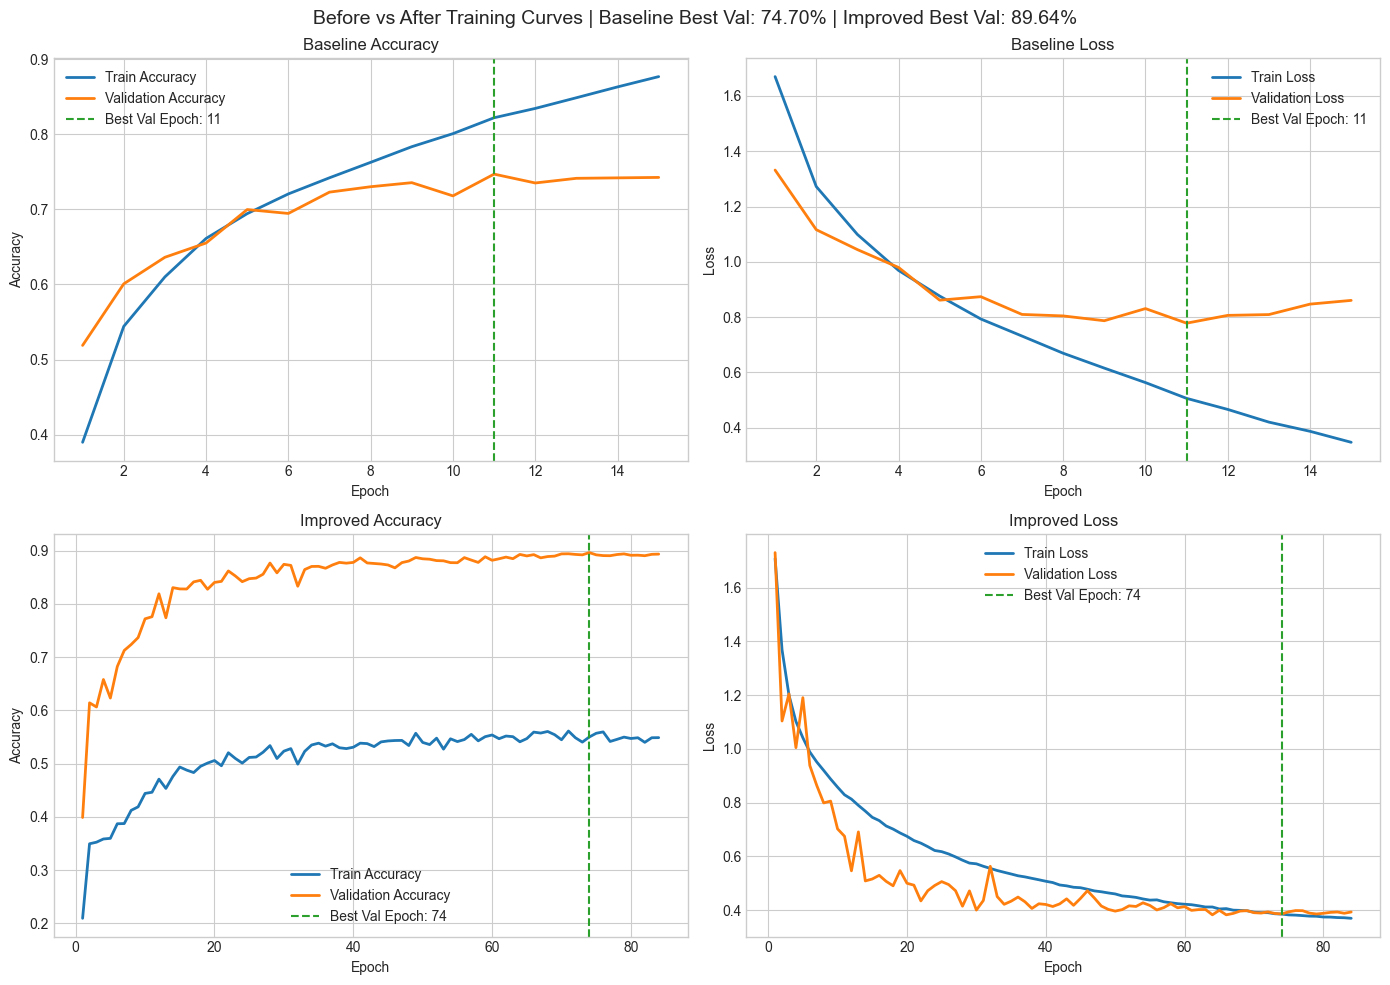

Baseline best validation accuracy: 74.70% at epoch 11
Improved best validation accuracy: 89.64% at epoch 74
Interpretation tip: use the test accuracy delta from the previous cell as the final before-vs-after quality check.


In [62]:
# Plot baseline vs improved histories for transparent before-vs-after comparison.
import matplotlib.pyplot as plt

baseline_data = baseline_history.history
improved_data = improved_history.history

base_epochs = range(1, len(baseline_data["accuracy"]) + 1)
imp_epochs = range(1, len(improved_data["accuracy"]) + 1)

base_best_epoch = int(np.argmax(baseline_data["val_accuracy"])) + 1
imp_best_epoch = int(np.argmax(improved_data["val_accuracy"])) + 1
base_best_val = baseline_data["val_accuracy"][base_best_epoch - 1]
imp_best_val = improved_data["val_accuracy"][imp_best_epoch - 1]

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(base_epochs, baseline_data["accuracy"], label="Train Accuracy", linewidth=2)
axes[0, 0].plot(base_epochs, baseline_data["val_accuracy"], label="Validation Accuracy", linewidth=2)
axes[0, 0].axvline(base_best_epoch, color="tab:green", linestyle="--", label=f"Best Val Epoch: {base_best_epoch}")
axes[0, 0].set_title("Baseline Accuracy")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()

axes[0, 1].plot(base_epochs, baseline_data["loss"], label="Train Loss", linewidth=2)
axes[0, 1].plot(base_epochs, baseline_data["val_loss"], label="Validation Loss", linewidth=2)
axes[0, 1].axvline(base_best_epoch, color="tab:green", linestyle="--", label=f"Best Val Epoch: {base_best_epoch}")
axes[0, 1].set_title("Baseline Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

axes[1, 0].plot(imp_epochs, improved_data["accuracy"], label="Train Accuracy", linewidth=2)
axes[1, 0].plot(imp_epochs, improved_data["val_accuracy"], label="Validation Accuracy", linewidth=2)
axes[1, 0].axvline(imp_best_epoch, color="tab:green", linestyle="--", label=f"Best Val Epoch: {imp_best_epoch}")
axes[1, 0].set_title("Improved Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].legend()

axes[1, 1].plot(imp_epochs, improved_data["loss"], label="Train Loss", linewidth=2)
axes[1, 1].plot(imp_epochs, improved_data["val_loss"], label="Validation Loss", linewidth=2)
axes[1, 1].axvline(imp_best_epoch, color="tab:green", linestyle="--", label=f"Best Val Epoch: {imp_best_epoch}")
axes[1, 1].set_title("Improved Loss")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()

fig.suptitle(
    "Before vs After Training Curves | "
    f"Baseline Best Val: {base_best_val * 100:.2f}% | Improved Best Val: {imp_best_val * 100:.2f}%",
    fontsize=14,
 )
plt.tight_layout()
plt.show()

print(f"Baseline best validation accuracy: {base_best_val * 100:.2f}% at epoch {base_best_epoch}")
print(f"Improved best validation accuracy: {imp_best_val * 100:.2f}% at epoch {imp_best_epoch}")
print("Interpretation tip: use the test accuracy delta from the previous cell as the final before-vs-after quality check.")

## 10) Export the Trained Improved Model
Save the trained `improved_model` in three deployment formats: `SavedModel`, `TFLite`, and `TFJS`.

In [ ]:
# Export the trained improved model to SavedModel, TFLite, and TFJS.
from pathlib import Path
import shutil
import sys
import os
import json
import importlib
import types

EXPORT_ROOT = Path(".")
SAVED_MODEL_DIR = EXPORT_ROOT / "saved_model"
TFLITE_DIR = EXPORT_ROOT / "tflite"
TFJS_DIR = EXPORT_ROOT / "tfjs_model"

for export_dir in [SAVED_MODEL_DIR, TFLITE_DIR, TFJS_DIR]:
    if export_dir.exists():
        shutil.rmtree(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)

# Create an inference-only copy that skips the random augmentation layer.
export_inputs = tf.keras.Input(shape=(32, 32, 3), name="inputs")
x = export_inputs
for layer in improved_model.layers:
    if layer.name == "data_augmentation":
        continue
    try:
        x = layer(x, training=False)
    except TypeError:
        x = layer(x)
export_model = tf.keras.Model(export_inputs, x, name="improved_cnn_export")

# Build once before exporting.
_ = export_model(tf.zeros((1, 32, 32, 3), dtype=tf.float32), training=False)

# 1) SavedModel
if hasattr(export_model, "export"):
    export_model.export(str(SAVED_MODEL_DIR))
else:
    tf.saved_model.save(export_model, str(SAVED_MODEL_DIR))
print(f"SavedModel exported to: {SAVED_MODEL_DIR}")

# 2) TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

(TFLITE_DIR / "model.tflite").write_bytes(tflite_model)
(TFLITE_DIR / "label.txt").write_text("\n".join(class_names), encoding="utf-8")
print(f"TFLite model exported to: {TFLITE_DIR / 'model.tflite'}")
print(f"Labels exported to: {TFLITE_DIR / 'label.txt'}")

# 3) TensorFlow.js
# Try the official converter first. If the environment blocks it,
# write a TFJS-compatible layers model directly.
def write_tfjs_layers_model(keras_model: tf.keras.Model, output_dir: Path) -> None:
    model_topology = json.loads(keras_model.to_json())
    weights_manifest = []
    binary_chunks = []

    for weight in keras_model.weights:
        arr = weight.numpy()
        if arr.dtype == np.float64:
            arr = arr.astype(np.float32)
        elif arr.dtype == np.int64:
            arr = arr.astype(np.int32)
        elif arr.dtype == np.bool_:
            arr = arr.astype(np.uint8)

        dtype_name = str(arr.dtype)
        if dtype_name not in {"float32", "int32", "uint8"}:
            arr = arr.astype(np.float32)
            dtype_name = "float32"

        weights_manifest.append(
            {
                "name": getattr(weight, "path", weight.name).replace(":0", ""),
                "shape": list(arr.shape),
                "dtype": "bool" if dtype_name == "uint8" else dtype_name,
            }
        )
        binary_chunks.append(arr.tobytes(order="C"))

    (output_dir / "group1-shard1of1.bin").write_bytes(b"".join(binary_chunks))
    tfjs_json = {
        "format": "layers-model",
        "generatedBy": f"TensorFlow {tf.__version__}",
        "convertedBy": "GitHub Copilot manual TFJS export",
        "modelTopology": model_topology,
        "weightsManifest": [
            {
                "paths": ["group1-shard1of1.bin"],
                "weights": weights_manifest,
            }
        ],
    }
    (output_dir / "model.json").write_text(json.dumps(tfjs_json), encoding="utf-8")


try:
    os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
    if not hasattr(np, "object"):
        np.object = object  # type: ignore[attr-defined]
    if not hasattr(np, "bool"):
        np.bool = bool  # type: ignore[attr-defined]
    if not hasattr(tf.compat.v1, "estimator"):
        tf.compat.v1.estimator = types.SimpleNamespace(Exporter=object)  # type: ignore[attr-defined]

    for module_name in list(sys.modules):
        if (
            module_name.startswith("tensorflowjs")
            or module_name.startswith("tensorflow_hub")
            or module_name.startswith("google.protobuf")
        ):
            sys.modules.pop(module_name, None)
    importlib.invalidate_caches()

    import tensorflowjs as tfjs

    tfjs.converters.save_keras_model(export_model, str(TFJS_DIR))
    print(f"TFJS model exported to: {TFJS_DIR}")
except Exception as exc:
    print(f"Official TFJS converter unavailable ({exc}). Writing TFJS-compatible files manually...")
    write_tfjs_layers_model(export_model, TFJS_DIR)
    print(f"TFJS-compatible model exported to: {TFJS_DIR}")

print("\nExported files:")
for path in sorted(EXPORT_ROOT.glob("saved_model/**/*")):
    if path.is_file():
        print(path)
for path in sorted(EXPORT_ROOT.glob("tflite/*")):
    if path.is_file():
        print(path)
for path in sorted(EXPORT_ROOT.glob("tfjs_model/*")):
    if path.is_file():
        print(path)


INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='inputs')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2342872027728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872031952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872032144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872031376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872030416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872030800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872030992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872031184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872031568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872033104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872033488: TensorSpec(shape=(), dtype=tf.r

INFO:tensorflow:Assets written to: C:\Users\Istamosh\AppData\Local\Temp\tmp2eopr1w_\assets


Saved artifact at 'C:\Users\Istamosh\AppData\Local\Temp\tmp2eopr1w_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='inputs')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  2342872027728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872031952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872032144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872031376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872030416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872030800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872030992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872031184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872031568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2342872033104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  234287203